In [23]:
#Data from era5 curated by Copernicus :
#https://sites.ecmwf.int/data/c3sci/era5-daily/data/
#As shown here : https://pulse.climate.copernicus.eu/

import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
import requests
import pandas as pd
from io import StringIO


In [24]:
def download_and_preprocess_csv(url, output_file_path):
    # Send a GET request to the URL
    response = requests.get(url)
    response.raise_for_status()  # Will raise an HTTPError for bad requests (4XX or 5XX)

    # Convert the text response to a pandas DataFrame
    data = StringIO(response.text)
    # Determine the line number where the correct header starts
    header_line = None
    for i, line in enumerate(data.readlines()):
        if line.startswith('date'):
            header_line = i
            break
    data.seek(0)  # Reset StringIO object to start

    # Read the CSV from the determined header line
    df = pd.read_csv(data, skiprows=header_line)

    # Save the cleaned data to a new CSV file
    df.to_csv(output_file_path, index=False)
    print(f"File saved to {output_file_path}")


In [25]:
# URL of the CSV file
url = 'https://sites.ecmwf.int/data/climatepulse/data/series/era5_daily_series_sst_60S-60N_ocean.csv'
# Path where the processed CSV will be saved
output_file_path = 'processed_era5_daily_series_sst.csv'

# Call the function
download_and_preprocess_csv(url, output_file_path)

File saved to processed_era5_daily_series_sst.csv


In [26]:
# Add the Nino index
#https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt
df = pd.read_csv('Nino_index.txt', delim_whitespace=True)
df['dates'] = pd.date_range(start='1950-01-01', end='2024-04-01', freq='MS')
df.set_index('dates', inplace=True)
ds_nino = xr.Dataset.from_dataframe(df)

In [27]:
# Load the CSV file into a DataFrame
data = pd.read_csv(output_file_path, delimiter=',')
ds = xr.Dataset.from_dataframe(data)
ds = xr.Dataset.from_dataframe(data.set_index('date'))
ds['date'] = ds['date'].astype('datetime64')

ds['day_of_year'] = ds['date'].dt.dayofyear
ds['year'] = ds['date'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('year')

#Create sst anomaly 1991-2020
ds_doy = ds.groupby('date.dayofyear')
ds_doy91_20 = ds.sel(date = slice('1991-01','2020-12')).groupby('date.dayofyear')
ano = (ds_doy - ds_doy91_20.mean(dim='date'))['sst'].data
ds = ds.assign(variables={"ano_91_20": (('date'), ano)})

ds1983 = ds.where(ds.year==1983)
ds1998 = ds.where(ds.year==1998)
ds2010 = ds.where(ds.year==2010)
ds2016 = ds.where(ds.year==2016)
ds2023 = ds.where(ds.year==2023)
ds2024 = ds.where(ds.year==2024)
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2023, ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'gold', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2023', '2024']
print('last date is '+ str(ds['date'][-1].data))

last date is 2024-09-10T00:00:00.000000000


0.013
0.013


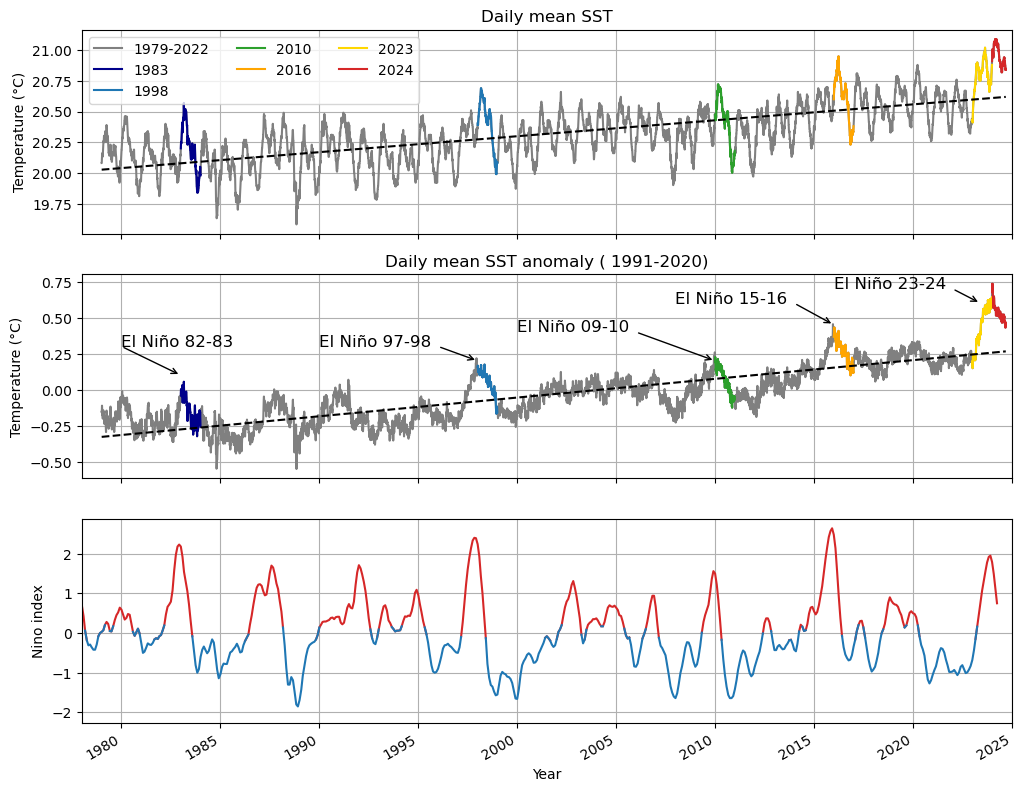

In [28]:
# Plotting
fig, (ax1,ax2,ax3) = plt.subplots(3, 1,figsize = (12,9))
for var,ax,title, in zip(['sst','ano_91_20'],[ax1,ax2],['Daily mean SST','Daily mean SST anomaly ( 1991-2020)']):
    ds[var].plot(label='1979-2022',color = 'grey',ax = ax)
    for i in np.arange(len(ds_list)):
        ds_list[i][var].plot(label=ds_lab[i], color=ds_col[i],ax = ax)
    # Linear regression for anomaly
    x_values = np.arange(len(ds['date'])).reshape(-1, 1)
    y_values = ds[var].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,3)
    print(slope)
    ax.plot(ds['date'], regression_line, linestyle='--', color='black') #label=f"Slope of the linear regression: {slope} °C/year"
    ax.set_title(title)
    ax.set_ylabel('Temperature (°C)')
    ax.grid()

ax2.text(pd.to_datetime('1980-01-01'), 0.3, 'El Niño 82-83' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('1983-01-01'), 0.1), xytext=(pd.to_datetime('1980-01-01'), 0.3),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('1990-01-01'), 0.3, 'El Niño 97-98' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('1998-01-01'), 0.2), xytext=(pd.to_datetime('1996-01-01'), 0.3),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2000-01-01'), 0.4, 'El Niño 09-10' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2010-01-01'), 0.2), xytext=(pd.to_datetime('2006-01-01'), 0.4),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2008-01-01'), 0.6, 'El Niño 15-16' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2016-01-01'), 0.45), xytext=(pd.to_datetime('2014-01-01'), 0.6),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2016-01-01'), .7, 'El Niño 23-24' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2023-06-01'), 0.6), xytext=(pd.to_datetime('2022-01-01'), 0.7),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
#Nino
ds_nino['ANOM'].where(ds_nino['ANOM'] >= -.2).plot(ax = ax3,color = 'tab:red')
ds_nino['ANOM'].where(ds_nino['ANOM'] <= .2).plot(ax = ax3,color = 'tab:blue')
ax3.set_ylabel('Nino index')
ax3.grid()
for ax in [ax1,ax2,ax3]:
    ax.set_xlim([pd.to_datetime('1978-01-01'),pd.to_datetime('2025-01-01')])
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('Year')
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax1.legend(ncol = 3)

plt.savefig('Figure/Fig_SST.png')

0.013
0.013


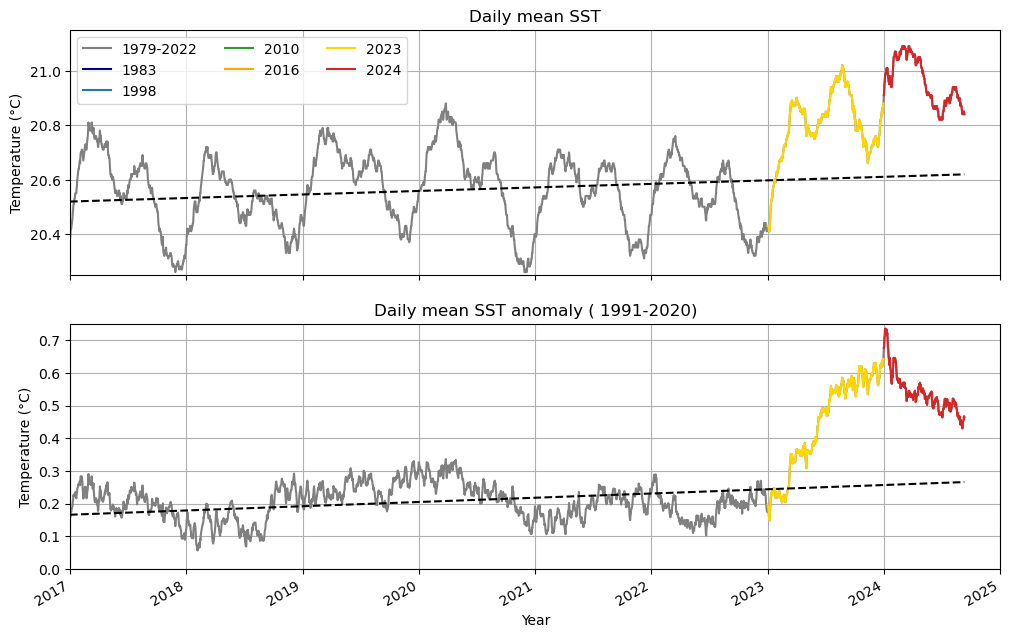

In [29]:
# Plotting Zoom
fig, (ax1,ax2) = plt.subplots(2, 1,figsize = (12,7))
for var,ax,title, in zip(['sst','ano_91_20'],[ax1,ax2],['Daily mean SST','Daily mean SST anomaly ( 1991-2020)']):
    ds[var].plot(label='1979-2022',color = 'grey',ax = ax)
    for i in np.arange(len(ds_list)):
        ds_list[i][var].plot(label=ds_lab[i], color=ds_col[i],ax = ax)
    # Linear regression for anomaly
    x_values = np.arange(len(ds['date'])).reshape(-1, 1)
    y_values = ds[var].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,3)
    print(slope)
    ax.plot(ds['date'], regression_line, linestyle='--', color='black') #label=f"Slope of the linear regression: {slope} °C/year"
    ax.set_title(title)
    ax.set_ylabel('Temperature (°C)')
    ax.grid()

ax1.set_xlabel('')
ax2.set_xlabel('Year')
ax1.set_xticklabels([])
ax1.legend(ncol = 3)
ax1.set_xlim([pd.to_datetime('2017-01-01'),pd.to_datetime('2025-01-01')])
ax2.set_xlim([pd.to_datetime('2017-01-01'),pd.to_datetime('2025-01-01')])
ax1.set_ylim([20.25,21.15])
ax2.set_ylim([0,0.75])
plt.savefig('Figure/Fig_SST_zoom.png')


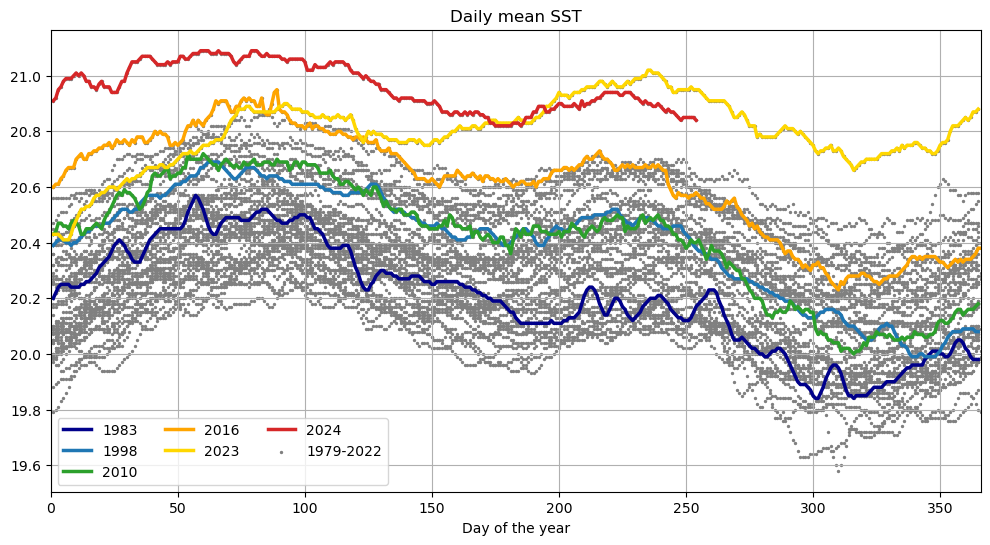

In [30]:
#Against day of the year for dramatic effect
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['sst'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['sst'],label=ds_lab[i], color=ds_col[i],linewidth = 2.5) #,s = 4)
plt.legend(ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST')
plt.savefig('Figure/Fig_SST2.png')

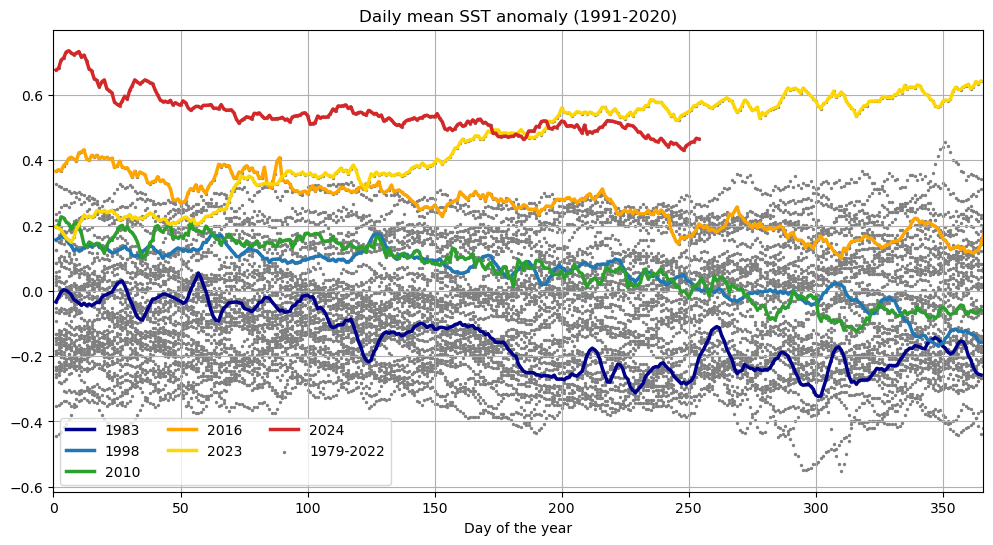

In [31]:
#Against day of the year for dramatic effect
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'],label=ds_lab[i], color=ds_col[i],linewidth = 2.5) #,s = 4)
plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST anomaly (1991-2020)')
plt.savefig('Figure/Fig_SST3.png')

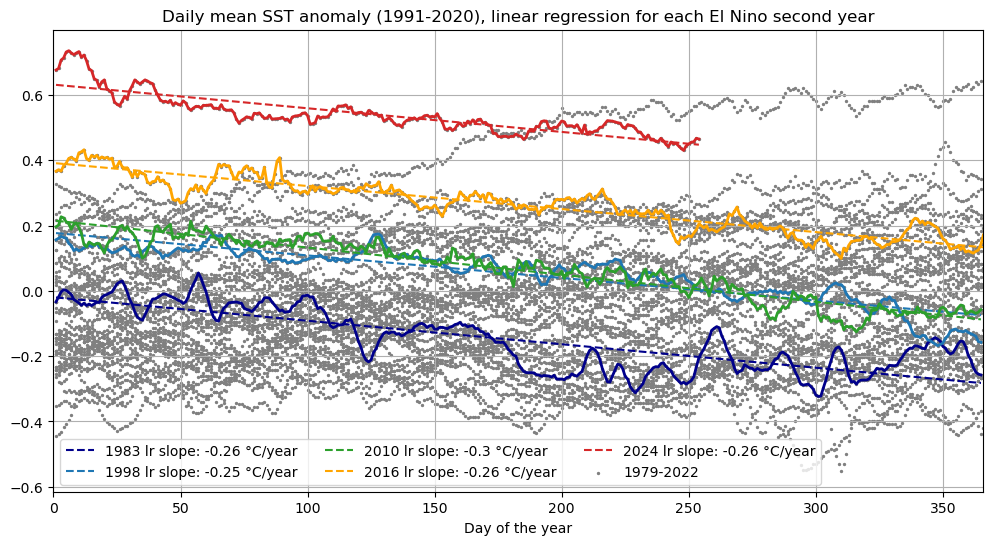

In [32]:
#Against day of the year for dramatic effect + linear trend for El Nino second year
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2024']
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'], color=ds_col[i],linewidth = 2)

    # Linear regression for anomaly
    x_values = np.arange(len(ds_list[i].dropna(dim = 'date')['day_of_year'])).reshape(-1, 1)
    y_values = ds_list[i]['ano_91_20'].dropna(dim = 'date').values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,2)
    plt.plot(ds_list[i].dropna(dim = 'date')['day_of_year'], regression_line, linestyle='--', color=ds_col[i]
           ,label=f"{ds_lab[i]} lr slope: {slope} °C/year")
    
plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST anomaly (1991-2020), linear regression for each El Nino second year')
plt.savefig('Figure/Fig_SST4.png')

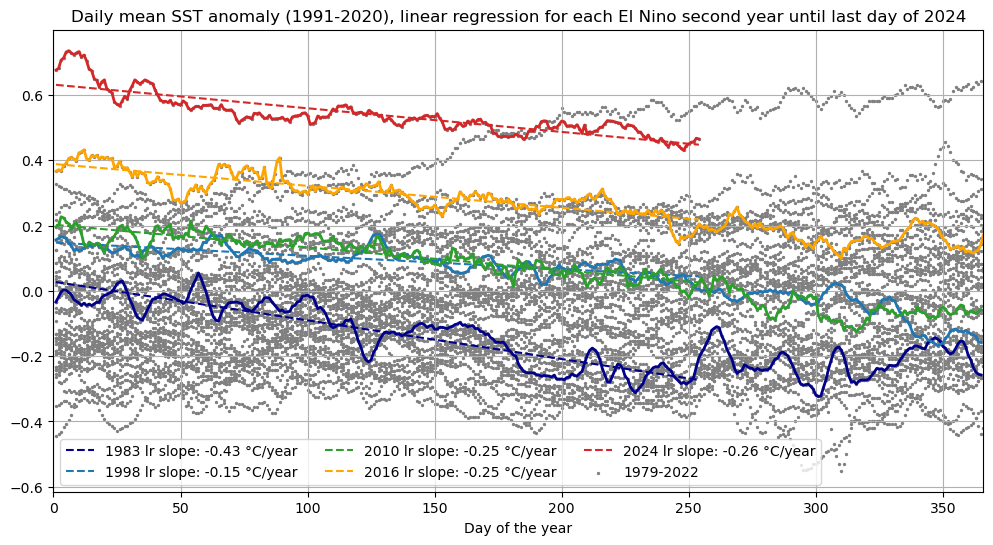

In [33]:
#Against day of the year for dramatic effect 
#+ linear trend for El Nino second year first 50 days to match 2024
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2024']

plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'], color=ds_col[i],linewidth = 2)

    # Linear regression for anomaly
    di = ds_list[i].dropna(dim = 'date')
    di = di.where((ds['day_of_year'] >= 1) & (ds['day_of_year'] <= ds['day_of_year'][-1].data)).dropna(dim = 'date')
    x_values = np.arange(len(di['day_of_year'])).reshape(-1, 1)
    y_values = di['ano_91_20'].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,2)
    plt.plot(di['day_of_year'], regression_line, linestyle='--', color=ds_col[i]
           ,label=f"{ds_lab[i]} lr slope: {slope} °C/year")

plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST anomaly (1991-2020), linear regression for each El Nino second year until last day of 2024')
plt.savefig('Figure/Fig_SST5.png')